# 문제 6 — 좌표 변환 체인과 회전축 복원

로봇 팔이 카메라가 본 물체를 집으려면 **camera → link → base** 로 이어지는
변환을 타고 내려와야 합니다. TF2 가 현장에서 해 주는 일을 직접 구현합니다.

$$T^{base}_{cam} = T^{base}_{link}\,T^{link}_{cam},\qquad
\mathbf{p}_{base}=T^{base}_{cam}\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}$$

윗첨자/아랫첨자가 **이웃끼리 상쇄**되도록 곱하면 순서를 틀리지 않습니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 6-1 | base→link, link→camera 두 변환을 정의하고 카메라 좌표를 base 로 바꾸기 | `CoordinateChain`, `default_chain`, `camera_point_to_base` |
| 6-2 | **왕복 검증** + 점군을 **반복문 없이** 한 번에 변환, 점 개수별 왕복 오차 그래프 (그래프 코드 제공) | `transform`, `base_point_to_camera` |
| 6-3 | base·camera 좌표계와 변환된 점군을 **3D 로 함께 시각화** (그림 코드 제공) | — |
| 6-4 | **고유값 분해로 회전축 복원**, 대각합으로 회전각, 축 불변 확인 | `axis_angle_from_matrix` |
| 6-5 | 단위 쿼터니언을 만들어 SciPy 와 비교하고 **부호가 반대로 나올 수 있는 이유** 설명 | `quaternion_from_axis_angle` |

> 완성한 체인은 `src/coordinate_chain.py` 로 내보냅니다.
> 모듈 ④ 미니 프로젝트에서 그대로 import 해 쓰므로 함수 이름을 바꾸지 마세요.
> `# --- 검증 ---` 셀과 그림 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.coordinate_chain import (CoordinateChain, base_point_to_camera,
                                  camera_point_to_base, default_chain)
from src.rotation import (axis_angle_from_matrix, quaternion_from_axis_angle, rodrigues,
                          rot_x, rot_y, rot_z)
from src.transform import inv_T, make_T, transform_points
from src.vectors import det, normalize

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T 가 나타내는 좌표계를 그린다. (그대로 쓰면 됩니다)"""
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold")


print("SciPy Rotation 사용 가능")

SciPy Rotation 사용 가능


## 6-1. 체인 구성과 카메라 → base 변환

`src/coordinate_chain.py` 의 `CoordinateChain` 은 부모-자식 관계를 등록해 두면
임의의 두 프레임 사이 변환을 알아서 조립합니다 (TF2 의 축소판).

지시문은 '임의의 회전·병진'을 쓰라고 하지만, 채점 수치를 맞추기 위해
**아래 값을 그대로** 씁니다 (`default_chain` 의 docstring 과 같은 값).

- `base → link` : z축 22.5도 회전 후 (0.35, 0.05, 0.45) m 이동
- `link → camera` : y축 -22.5도, x축 67.5도 회전(y 먼저 곱함: `rot_y @ rot_x`) 후 (0.12, 0.04, 0.18) m 이동

문제 2 의 `rot_*` 와 문제 5 의 `make_T`/`inv_T` 를 그대로 재사용합니다.

**할 일** — `CoordinateChain` 의 `_path_to_root`, `T_from_root`, `T`, `transform` 과
`default_chain`, `camera_point_to_base` 를 구현하고 아래를 확인하세요.

In [2]:
chain = default_chain()
p_cam = np.array([0.15, -0.08, 0.65])

T_base_link = chain.get("base", "link")
T_link_cam = chain.get("link", "camera")
T_base_cam = chain.T("base", "camera")
p_base = camera_point_to_base(p_cam, chain)

print("T_base_link:\n", T_base_link)
print("T_link_cam:\n", T_link_cam)
print("T_base_cam:\n", T_base_cam)
print("체인 곱과 일치:", np.allclose(T_base_cam, T_base_link @ T_link_cam))
print("p_base:", p_base)
print("base 원점에서 거리:", np.linalg.norm(p_base))
print("카메라 원점의 base 위치:", T_base_cam[:3, 3])

T_base_link:
 [[ 0.92388  -0.382683  0.        0.35    ]
 [ 0.382683  0.92388   0.        0.05    ]
 [ 0.        0.        1.        0.45    ]
 [ 0.        0.        0.        1.      ]]
T_link_cam:
 [[ 0.92388  -0.353553 -0.146447  0.12    ]
 [ 0.        0.382683 -0.92388   0.04    ]
 [ 0.382683  0.853553  0.353553  0.18    ]
 [ 0.        0.        0.        1.      ]]
T_base_cam:
 [[ 0.853553 -0.473087  0.218254  0.445558]
 [ 0.353553  0.218254 -0.909596  0.132877]
 [ 0.382683  0.853553  0.353553  0.63    ]
 [ 0.        0.        0.        1.      ]]
체인 곱과 일치: True
p_base: [ 0.753304 -0.422788  0.848928]
base 원점에서 거리: 1.2111540942117602
카메라 원점의 base 위치: [0.445558 0.132877 0.63    ]


In [3]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("base->link 가 지정한 값 (z 22.5도, (0.35, 0.05, 0.45))",
           np.allclose(T_base_link, make_T(rot_z(np.deg2rad(22.5)), [0.35, 0.05, 0.45])))
ok &= check("link->camera 가 지정한 값 (rot_y(-22.5) @ rot_x(67.5), (0.12, 0.04, 0.18))",
            np.allclose(T_link_cam, make_T(rot_y(np.deg2rad(-22.5)) @ rot_x(np.deg2rad(67.5)),
                                           [0.12, 0.04, 0.18])))
ok &= check("체인 조립이 행렬 곱과 일치", np.allclose(T_base_cam, T_base_link @ T_link_cam))
ok &= check("합성 변환이 유효한 동차변환 (회전부 det = 1)", np.isclose(det(T_base_cam[:3, :3]), 1.0))
ok &= check("회전부가 직교", np.allclose(T_base_cam[:3, :3].T @ T_base_cam[:3, :3], np.eye(3)))
ok &= check("p_base 가 T @ [p_cam, 1] 과 같다",
            np.allclose(p_base, (T_base_cam @ np.append(p_cam, 1.0))[:3]))
ok &= check("카메라 원점(0,0,0)은 base 에서 T 의 병진 성분",
            np.allclose(camera_point_to_base([0, 0, 0], chain), T_base_cam[:3, 3]))
ok &= check("역방향 체인 T(camera<-base) == inv(T(base<-camera))",
            np.allclose(chain.T("camera", "base"), inv_T(T_base_cam)))
ok &= check("거리는 변환에 대해 불변 (두 점 사이 거리)",
            np.isclose(np.linalg.norm(camera_point_to_base([1., 0., 0.], chain)
                                      - camera_point_to_base([0., 0., 0.], chain)), 1.0))
print("\n6-1 전체 통과:", ok)

[PASS] base->link 가 지정한 값 (z 22.5도, (0.35, 0.05, 0.45))
[PASS] link->camera 가 지정한 값 (rot_y(-22.5) @ rot_x(67.5), (0.12, 0.04, 0.18))
[PASS] 체인 조립이 행렬 곱과 일치
[PASS] 합성 변환이 유효한 동차변환 (회전부 det = 1)
[PASS] 회전부가 직교
[PASS] p_base 가 T @ [p_cam, 1] 과 같다
[PASS] 카메라 원점(0,0,0)은 base 에서 T 의 병진 성분
[PASS] 역방향 체인 T(camera<-base) == inv(T(base<-camera))
[PASS] 거리는 변환에 대해 불변 (두 점 사이 거리)

6-1 전체 통과: True


## 6-2. 왕복 검증과 점군 벡터화

base로 바꾼 좌표를 다시 camera 기준으로 되돌리면 원래 값이 나와야 합니다.

### 관찰과 해석

- 왕복 오차가 점 개수에 따라 어떻게 변하는가: 점 개수가 늘어도 최대 오차와 RMS 오차는 기계 정밀도 수준에 머문다.
- 그 이유: 각 점을 독립적으로 같은 변환과 역변환에 통과시키므로 오차가 점 개수 방향으로 누적되지 않는다.
- 벡터화가 반복문보다 빠른 이유: NumPy가 점군 전체의 행렬 곱을 한 번에 수행해 파이썬 반복과 함수 호출 오버헤드를 줄이기 때문이다.

In [4]:
p_back = base_point_to_camera(p_base, chain)
print("p_back:", p_back)
print("단일 점 왕복 오차:", np.linalg.norm(p_back - p_cam))

p_back: [ 0.15 -0.08  0.65]
단일 점 왕복 오차: 1.5011122659325205e-16


In [5]:
P_cam = rng.uniform(-0.5, 0.5, size=(1000, 3)) + np.array([0.0, 0.0, 0.8])
P_base = chain.transform("base", "camera", P_cam)
P_back = chain.transform("camera", "base", P_base)
loop_base = np.array([camera_point_to_base(p, chain) for p in P_cam])
print("P_base shape:", P_base.shape)
print("벡터화와 반복문 일치:", np.allclose(P_base, loop_base))
print("점군 왕복 최대 오차:", np.max(np.linalg.norm(P_back - P_cam, axis=1)))

P_base shape: (1000, 3)
벡터화와 반복문 일치: True
점군 왕복 최대 오차: 4.611102534756203e-16


In [6]:
counts = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
max_errs, rms_errs, times_vec, times_loop = [], [], [], []

for n in counts:
    points = rng.uniform(-0.5, 0.5, size=(n, 3)) + np.array([0.0, 0.0, 0.8])
    t0 = time.perf_counter()
    points_base = chain.transform("base", "camera", points)
    points_back = chain.transform("camera", "base", points_base)
    times_vec.append(time.perf_counter() - t0)
    errors = np.linalg.norm(points_back - points, axis=1)
    max_errs.append(float(np.max(errors)))
    rms_errs.append(float(np.sqrt(np.mean(errors * errors))))
    if n <= 10_000:
        t0 = time.perf_counter()
        loop_back = np.array([base_point_to_camera(camera_point_to_base(p, chain), chain) for p in points])
        times_loop.append(time.perf_counter() - t0)
        print("N={}, max={:.3e}, RMS={:.3e}, vec={:.3e}s, loop={:.3e}s".format(
            n, max_errs[-1], rms_errs[-1], times_vec[-1], times_loop[-1]))
    else:
        times_loop.append(np.nan)
        print("N={}, max={:.3e}, RMS={:.3e}, vec={:.3e}s".format(
            n, max_errs[-1], rms_errs[-1], times_vec[-1]))

N=1, max=0.000e+00, RMS=0.000e+00, vec=1.309e-04s, loop=4.575e-05s
N=10, max=2.483e-16, RMS=1.520e-16, vec=4.684e-05s, loop=2.386e-04s
N=100, max=4.475e-16, RMS=1.473e-16, vec=4.783e-05s, loop=2.520e-03s
N=1000, max=4.710e-16, RMS=1.413e-16, vec=5.811e-05s, loop=2.119e-02s


N=10000, max=5.155e-16, RMS=1.439e-16, vec=6.027e-04s, loop=1.645e-01s


N=100000, max=5.661e-16, RMS=1.434e-16, vec=3.166e-03s


N=1000000, max=5.979e-16, RMS=1.434e-16, vec=4.992e-02s


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


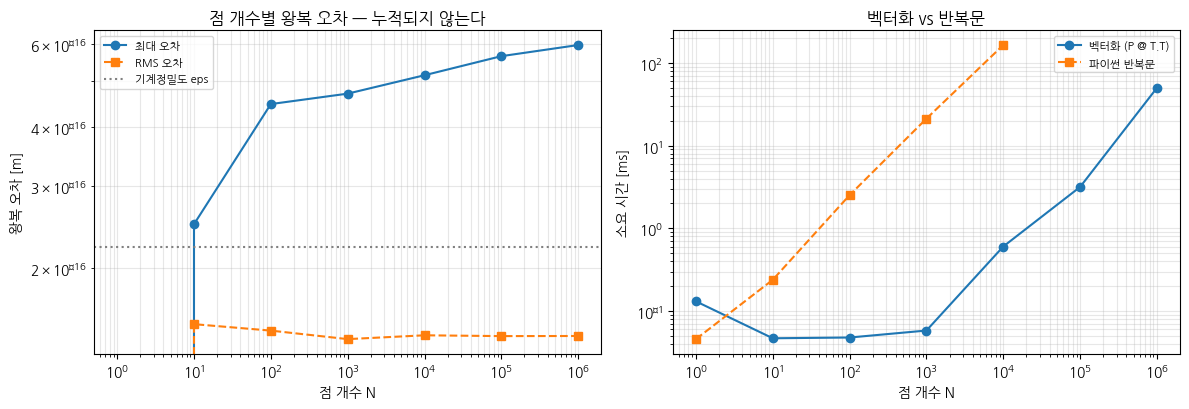

In [7]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].loglog(counts, max_errs, "o-", label="최대 오차")
axes[0].loglog(counts, rms_errs, "s--", label="RMS 오차")
axes[0].axhline(np.finfo(float).eps, color="gray", ls=":", label="기계정밀도 eps")
axes[0].set_xlabel("점 개수 N")
axes[0].set_ylabel("왕복 오차 [m]")
axes[0].set_title("점 개수별 왕복 오차 — 누적되지 않는다")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)

valid = ~np.isnan(times_loop)
axes[1].loglog(counts, np.array(times_vec) * 1e3, "o-", label="벡터화 (P @ T.T)")
axes[1].loglog(np.array(counts)[valid], np.array(times_loop)[valid] * 1e3, "s--",
               label="파이썬 반복문")
axes[1].set_xlabel("점 개수 N")
axes[1].set_ylabel("소요 시간 [ms]")
axes[1].set_title("벡터화 vs 반복문")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("단일 점 왕복 오차가 기계정밀도 수준", np.linalg.norm(p_back - p_cam) < 1e-15)
ok &= check("점군 왕복 오차도 기계정밀도 수준", max(max_errs) < 1e-14)
ok &= check("오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)", max_errs[-1] < 1e-14)
ok &= check("점군 shape 이 유지된다", P_base.shape == P_cam.shape == (1000, 3))
ok &= check("벡터화 결과 == 반복문 결과",
            np.allclose(P_base, np.array([camera_point_to_base(p, chain) for p in P_cam])))
ok &= check("P_back == P_cam", np.allclose(P_back, P_cam))
ok &= check("1만 개에서 벡터화가 반복문보다 빠르다",
            times_vec[counts.index(10_000)] < times_loop[counts.index(10_000)])
ok &= check("변환이 점 사이 거리를 보존",
            np.allclose(np.linalg.norm(P_base[1:] - P_base[:-1], axis=1),
                        np.linalg.norm(P_cam[1:] - P_cam[:-1], axis=1)))
print("\n6-2 전체 통과:", ok)

[PASS] 단일 점 왕복 오차가 기계정밀도 수준
[PASS] 점군 왕복 오차도 기계정밀도 수준
[PASS] 오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)
[PASS] 점군 shape 이 유지된다
[PASS] 벡터화 결과 == 반복문 결과
[PASS] P_back == P_cam
[PASS] 1만 개에서 벡터화가 반복문보다 빠르다
[PASS] 변환이 점 사이 거리를 보존

6-2 전체 통과: True


## 6-3. 좌표계와 점군 3D 시각화

base·link·camera 세 좌표계와 변환된 점군을 함께 그립니다.

### 판단 근거

- 카메라 좌표계에서 z축 앞에 있던 점군의 중심이 변환 후에도 카메라 좌표계의 z축 방향에 있고, link와 camera의 원점이 체인 변환 위치에 맞게 배치된다.

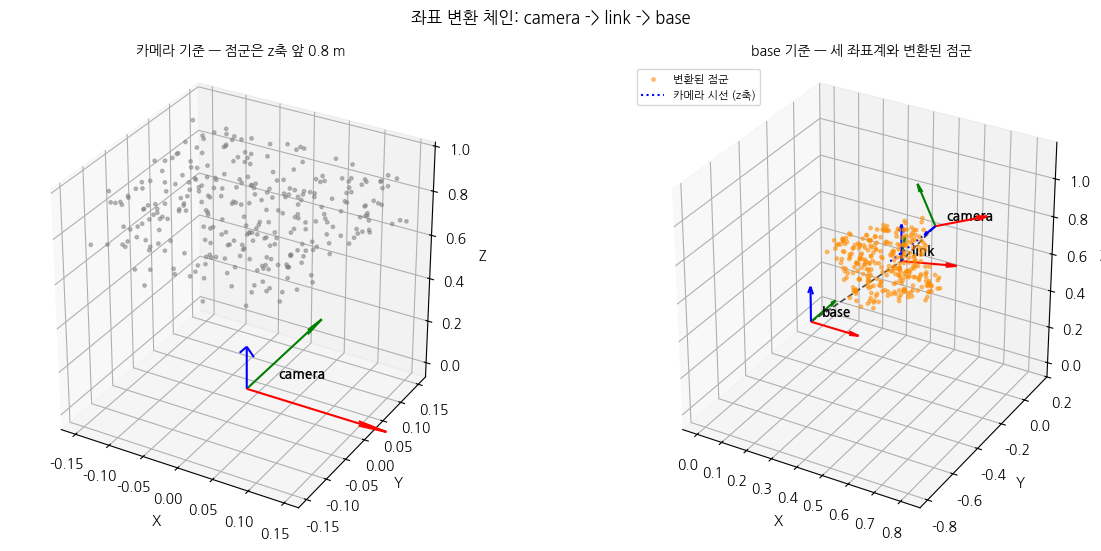

In [9]:
# --- 3D 그림 (제공 코드) ---
P_show_cam = rng.uniform(-0.15, 0.15, size=(300, 3)) + np.array([0.0, 0.0, 0.8])
P_show_base = chain.transform("base", "camera", P_show_cam)

fig = plt.figure(figsize=(13, 5.4))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(*P_show_cam.T, s=6, alpha=0.5, color="gray")
draw_frame(ax, np.eye(4), scale=0.2, name="camera")
ax.set_title("카메라 기준 — 점군은 z축 앞 0.8 m", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(*P_show_base.T, s=6, alpha=0.5, color="darkorange", label="변환된 점군")
draw_frame(ax, np.eye(4), scale=0.2, name="base")
draw_frame(ax, chain.T_from_root("link"), scale=0.2, name="link")
draw_frame(ax, T_base_cam, scale=0.2, name="camera")

pts = np.array([[0, 0, 0], chain.T_from_root("link")[:3, 3], T_base_cam[:3, 3]])
ax.plot(*pts.T, "k--", lw=1.2, alpha=0.7)
cam_o = T_base_cam[:3, 3]
ax.plot(*np.array([cam_o, P_show_base.mean(axis=0)]).T, color="b", ls=":", lw=1.5,
        label="카메라 시선 (z축)")

ax.set_title("base 기준 — 세 좌표계와 변환된 점군", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("좌표 변환 체인: camera -> link -> base", fontsize=12)
fig.tight_layout()
plt.show()

In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
centroid_base = P_show_base.mean(axis=0)
cam_axis_z = T_base_cam[:3, 2]
to_centroid = normalize(centroid_base - cam_o)

ok = check("점군 중심이 카메라 z축(시선) 방향에 있다", np.dot(to_centroid, cam_axis_z) > 0.99)
ok &= check("점군 중심까지 거리가 약 0.8 m",
            np.isclose(np.linalg.norm(centroid_base - cam_o), 0.8, atol=0.02))
ok &= check("점군의 퍼짐(분산)이 변환 후에도 보존",
            np.isclose(np.trace(np.cov(P_show_cam.T)), np.trace(np.cov(P_show_base.T))))
ok &= check("link 원점이 base 에서 (0.35, 0.05, 0.45)",
            np.allclose(chain.T_from_root("link")[:3, 3], [0.35, 0.05, 0.45]))
print("\n6-3 전체 통과:", ok)

[PASS] 점군 중심이 카메라 z축(시선) 방향에 있다
[PASS] 점군 중심까지 거리가 약 0.8 m
[PASS] 점군의 퍼짐(분산)이 변환 후에도 보존
[PASS] link 원점이 base 에서 (0.35, 0.05, 0.45)

6-3 전체 통과: True


## 6-4. 고유값 분해로 회전축 복원

### 유도와 규약

- trace와 회전각의 관계: $\operatorname{tr}(R)=1+2\cos\theta$이므로 $\theta=\arccos((\operatorname{tr}(R)-1)/2)$이다.
- 축의 부호를 정하는 방법: $R-R^T=2\sin\theta[k]_{\times}$의 반대칭 성분 방향과 고유벡터의 내적을 양수로 맞춘다.
- theta = 0 / theta = pi 처리: $\theta=0$에서는 축이 유일하지 않아 +x축을 규약으로 사용하고, $\theta=\pi$에서는 반대 부호가 같은 회전을 나타내므로 첫 번째 유효 성분을 양수로 정한다.

In [11]:
R_chain = T_base_cam[:3, :3]

eigvals, eigvecs = np.linalg.eig(R_chain)
axis, angle = axis_angle_from_matrix(R_chain)
angle_deg = np.degrees(angle)
cos_from_trace = np.clip((np.trace(R_chain) - 1.0) / 2.0, -1.0, 1.0)
R_chain_axis = R_chain @ axis
R_rebuilt = rodrigues(axis, angle)

print("고유값:", eigvals)
print("복원 축:", axis)
print("복원 각도 [deg]:", angle_deg)
print("trace 기반 cos(theta):", cos_from_trace)
print("R @ axis:", R_chain_axis)
print("R 재구성 일치:", np.allclose(R_rebuilt, R_chain))

고유값: [1.      +0.j       0.212681+0.977122j 0.212681-0.977122j]
복원 축: [ 0.902216 -0.084139  0.422998]
복원 각도 [deg]: 77.72051288260144
trace 기반 cos(theta): 0.21268057337163615
R @ axis: [ 0.902216 -0.084139  0.422998]
R 재구성 일치: True


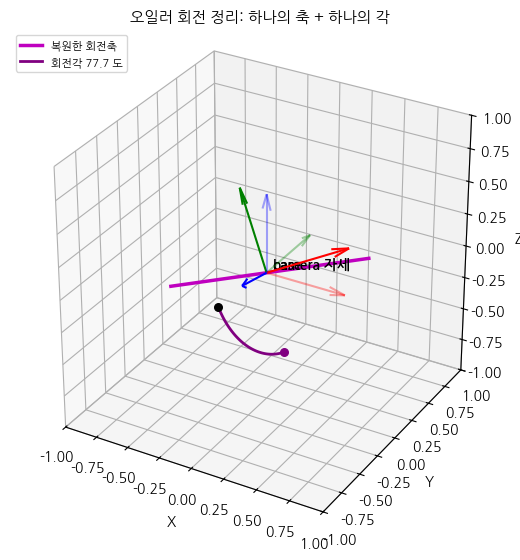

In [12]:
# --- 3D 그림 (제공 코드) : base 좌표계, 복원한 회전축, 축 둘레를 theta 만큼 도는 호 ---
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")

draw_frame(ax, np.eye(4), scale=0.6, name="base", alpha=0.35)
draw_frame(ax, make_T(R_chain, [0, 0, 0]), scale=0.6, name="camera 자세")

k = axis * 0.9
ax.plot([-k[0], k[0]], [-k[1], k[1]], [-k[2], k[2]], "m-", lw=2.5, label="복원한 회전축")

perp = normalize(np.cross(axis, [0, 0, 1] if abs(axis[2]) < 0.9 else [1, 0, 0])) * 0.55
arc = np.array([rodrigues(axis, a) @ perp for a in np.linspace(0, angle, 60)])
ax.plot(*arc.T, color="purple", lw=2, label="회전각 {:.1f} 도".format(np.degrees(angle)))
ax.scatter(*perp, color="k", s=30)
ax.scatter(*arc[-1], color="purple", s=30)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("오일러 회전 정리: 하나의 축 + 하나의 각", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("고유값 중 하나가 1", np.isclose(np.min(np.abs(eigvals - 1.0)), 0.0))
ok &= check("고유값의 절댓값이 모두 1", np.allclose(np.abs(eigvals), 1.0))
ok &= check("복원한 축이 단위벡터", np.isclose(np.linalg.norm(axis), 1.0))
ok &= check("R @ axis == axis (축 불변)", np.allclose(R_chain @ axis, axis))
ok &= check("R^T @ axis == axis (역회전에도 불변)", np.allclose(R_chain.T @ axis, axis))
ok &= check("각이 (0, pi) 범위", 0.0 < angle < np.pi)
ok &= check("trace 로 구한 각과 일치: tr(R) = 1 + 2 cos(theta)",
            np.isclose(np.trace(R_chain), 1 + 2 * np.cos(angle)))
ok &= check("trace 로 구한 각이 고유값 위상과 일치",
            np.isclose(angle, np.abs(np.angle(eigvals[np.argmax(np.abs(eigvals.imag))]))))
ok &= check("축의 부호가 맞다 (R - R^T = 2 sin(theta) [k]x 의 방향)",
            np.allclose((R_chain - R_chain.T) / (2 * np.sin(angle)),
                        np.array([[0, -axis[2], axis[1]], [axis[2], 0, -axis[0]], [-axis[1], axis[0], 0]])))
ok &= check("복원한 축/각으로 R 을 재구성할 수 있다", np.allclose(R_rebuilt, R_chain))
ok &= check("SciPy 의 회전벡터 크기와 일치",                                                   # 비교 대상
            np.isclose(angle, np.linalg.norm(Rotation.from_matrix(R_chain).as_rotvec())))
print("\n6-4 전체 통과:", ok)

[PASS] 고유값 중 하나가 1
[PASS] 고유값의 절댓값이 모두 1
[PASS] 복원한 축이 단위벡터
[PASS] R @ axis == axis (축 불변)
[PASS] R^T @ axis == axis (역회전에도 불변)
[PASS] 각이 (0, pi) 범위
[PASS] trace 로 구한 각과 일치: tr(R) = 1 + 2 cos(theta)
[PASS] trace 로 구한 각이 고유값 위상과 일치
[PASS] 축의 부호가 맞다 (R - R^T = 2 sin(theta) [k]x 의 방향)
[PASS] 복원한 축/각으로 R 을 재구성할 수 있다
[PASS] SciPy 의 회전벡터 크기와 일치

6-4 전체 통과: True


## 6-5. 단위 쿼터니언과 SciPy 비교 — 부호는 왜 반대로 나올 수 있나

### 부호 차이의 이유와 실무 대처

- 관찰: 직접 계산한 쿼터니언과 SciPy 결과는 전체 부호가 같거나 반대일 수 있지만 같은 회전을 나타낸다.
- 이유: $q$와 $-q$는 동일한 3차원 회전으로 사원수의 이중 덮개를 이룬다.
- 비교할 때: 성분 직접 비교 대신 `q`와 `-q` 중 가까운 쪽 또는 $|q\cdot q_{ref}|$를 비교한다.
- 보간(SLERP)·필터에 쓸 때: 연속 프레임에서 내적이 음수면 한 쪽 쿼터니언의 부호를 뒤집어 짧은 경로와 연속성을 유지한다.

In [14]:
q_mine = quaternion_from_axis_angle(axis, angle)
q_scipy = Rotation.from_matrix(R_chain).as_quat()
q_flip = quaternion_from_axis_angle(-axis, 2 * np.pi - angle)

print("q_mine:", q_mine)
print("q_scipy:", q_scipy)
print("부호 무시 일치:", np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy))
print("|q · q_scipy|:", abs(q_mine @ q_scipy))
print("q 회전행렬 오차:", np.max(np.abs(Rotation.from_quat(q_mine).as_matrix() - R_chain)))
print("-q 회전행렬 오차:", np.max(np.abs(Rotation.from_quat(-q_mine).as_matrix() - R_chain)))
print("q_flip == -q_mine:", np.allclose(q_flip, -q_mine))

q_mine: [ 0.566071 -0.052791  0.265399  0.778679]
q_scipy: [ 0.566071 -0.052791  0.265399  0.778679]
부호 무시 일치: True
|q · q_scipy|: 1.0
q 회전행렬 오차: 2.220446049250313e-16
-q 회전행렬 오차: 2.220446049250313e-16
q_flip == -q_mine: True


In [15]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("직접 계산한 쿼터니언이 단위 노름", np.isclose(np.linalg.norm(q_mine), 1.0))
ok &= check("(x,y,z,w) 순서: w == cos(theta/2)", np.isclose(q_mine[3], np.cos(angle / 2)))
ok &= check("벡터부 == axis * sin(theta/2)", np.allclose(q_mine[:3], axis * np.sin(angle / 2)))
ok &= check("SciPy 결과와 부호 무시하고 일치",
            np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy))
ok &= check("|q · q_scipy| == 1 (같은 회전)", np.isclose(abs(q_mine @ q_scipy), 1.0))
ok &= check("q 로 복원한 R 이 원본과 일치",
            np.allclose(Rotation.from_quat(q_mine).as_matrix(), R_chain))
ok &= check("-q 로 복원한 R 도 원본과 일치 (이중 덮개)",
            np.allclose(Rotation.from_quat(-q_mine).as_matrix(), R_chain))
ok &= check("축 반전 + (2pi - theta) 가 -q 를 준다", np.allclose(q_flip, -q_mine))
ok &= check("무작위 회전 100개에서 부호 무시 시 항상 일치", all(
    (lambda A, B: np.allclose(A, B) or np.allclose(A, -B))(
        quaternion_from_axis_angle(*axis_angle_from_matrix(Rr)),
        Rotation.from_matrix(Rr).as_quat())
    for Rr in [rot_z(a) @ rot_y(b_) @ rot_x(c)
               for a, b_, c in rng.uniform(-np.pi, np.pi, (100, 3))]))
print("\n6-5 전체 통과:", ok)

[PASS] 직접 계산한 쿼터니언이 단위 노름
[PASS] (x,y,z,w) 순서: w == cos(theta/2)
[PASS] 벡터부 == axis * sin(theta/2)
[PASS] SciPy 결과와 부호 무시하고 일치
[PASS] |q · q_scipy| == 1 (같은 회전)
[PASS] q 로 복원한 R 이 원본과 일치
[PASS] -q 로 복원한 R 도 원본과 일치 (이중 덮개)
[PASS] 축 반전 + (2pi - theta) 가 -q 를 준다
[PASS] 무작위 회전 100개에서 부호 무시 시 항상 일치

6-5 전체 통과: True


## 답안 템플릿 정리

In [16]:
summary = """
1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = {p_cam}  ->  p_base = {p_base}
   사용한 체인: T(base<-camera) =
{T_base_cam}

2. 왕복 검증: 단일 점 오차 {single_err:.3e}, 점군 100만 개에서 최대 {million_err:.3e}
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 각 점을 독립적으로 같은 변환과 역변환으로 처리하기 때문이다.
   - 벡터화 vs 반복문 속도 (1만 개): {speedup:.2f} 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 카메라 z축 앞 점군의 중심이 변환 후에도 카메라 시선 방향에 놓인다.

4. 복원한 회전축: {axis} / 회전각: {angle_deg:.4f} 도
   - 축 불변 검증: {axis_ok} (|R k - k| = {axis_err:.3e})
   - 축과 각을 구한 방법: 고유값 1의 고유벡터와 trace 관계를 사용했다.

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: {q_mine}
   - SciPy: {q_scipy}
   - 부호 무시하고 일치: {quat_ok}, |q · q_scipy| = {quat_dot:.6f}
   - 부호 차이의 이유: q와 -q가 같은 3차원 회전을 나타내기 때문이다.
""".format(
    p_cam=np.array2string(p_cam, precision=5),
    p_base=np.array2string(p_base, precision=5),
    T_base_cam=np.array2string(T_base_cam, precision=5),
    single_err=np.linalg.norm(p_back - p_cam),
    million_err=max_errs[-1],
    speedup=times_loop[counts.index(10_000)] / times_vec[counts.index(10_000)],
    axis=np.array2string(axis, precision=5),
    angle_deg=angle_deg,
    axis_ok=np.allclose(R_chain @ axis, axis),
    axis_err=np.linalg.norm(R_chain @ axis - axis),
    q_mine=np.array2string(q_mine, precision=5),
    q_scipy=np.array2string(q_scipy, precision=5),
    quat_ok=np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy),
    quat_dot=abs(q_mine @ q_scipy),
)
print(summary)


1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = [ 0.15 -0.08  0.65]  ->  p_base = [ 0.7533  -0.42279  0.84893]
   사용한 체인: T(base<-camera) =
[[ 0.85355 -0.47309  0.21825  0.44556]
 [ 0.35355  0.21825 -0.9096   0.13288]
 [ 0.38268  0.85355  0.35355  0.63   ]
 [ 0.       0.       0.       1.     ]]

2. 왕복 검증: 단일 점 오차 1.501e-16, 점군 100만 개에서 최대 5.979e-16
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 각 점을 독립적으로 같은 변환과 역변환으로 처리하기 때문이다.
   - 벡터화 vs 반복문 속도 (1만 개): 272.91 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 카메라 z축 앞 점군의 중심이 변환 후에도 카메라 시선 방향에 놓인다.

4. 복원한 회전축: [ 0.90222 -0.08414  0.423  ] / 회전각: 77.7205 도
   - 축 불변 검증: True (|R k - k| = 2.289e-16)
   - 축과 각을 구한 방법: 고유값 1의 고유벡터와 trace 관계를 사용했다.

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: [ 0.56607 -0.05279  0.2654   0.77868]
   - SciPy: [ 0.56607 -0.05279  0.2654   0.77868]
   - 부호 무시하고 일치: True, |q · q_scipy| = 1.000000
   - 부호 차이의 이유: q와 -q가 같은 3차원 회전을 나타내기 때문이다.

